In [1]:
# @title 3D Visualization Utilities

import json
import random
import io
import ast
import math
import cv2
import numpy as np
from PIL import ImageColor
import matplotlib.pyplot as plt
import os
import base64
from openai import OpenAI
from PIL import Image

def convert_3dbbox(point, cam_params):
    """Convert 3D bounding box to 2D image coordinates"""
    x, y, z, x_size, y_size, z_size, pitch, yaw, roll = point
    hx, hy, hz = x_size / 2, y_size / 2, z_size / 2
    local_corners = [
        [ hx,  hy,  hz],
        [ hx,  hy, -hz],
        [ hx, -hy,  hz],
        [ hx, -hy, -hz],
        [-hx,  hy,  hz],
        [-hx,  hy, -hz],
        [-hx, -hy,  hz],
        [-hx, -hy, -hz]
    ]

    def rotate_xyz(_point, _pitch, _yaw, _roll):
        x0, y0, z0 = _point
        x1 = x0
        y1 = y0 * math.cos(_pitch) - z0 * math.sin(_pitch)
        z1 = y0 * math.sin(_pitch) + z0 * math.cos(_pitch)

        x2 = x1 * math.cos(_yaw) + z1 * math.sin(_yaw)
        y2 = y1
        z2 = -x1 * math.sin(_yaw) + z1 * math.cos(_yaw)

        x3 = x2 * math.cos(_roll) - y2 * math.sin(_roll)
        y3 = x2 * math.sin(_roll) + y2 * math.cos(_roll)
        z3 = z2

        return [x3, y3, z3]
    
    img_corners = []
    for corner in local_corners:
        rotated = rotate_xyz(corner, np.deg2rad(pitch), np.deg2rad(yaw), np.deg2rad(roll))
        X, Y, Z = rotated[0] + x, rotated[1] + y, rotated[2] + z
        if Z > 0:
            x_2d = cam_params['fx'] * (X / Z) + cam_params['cx']
            y_2d = cam_params['fy'] * (Y / Z) + cam_params['cy']
            img_corners.append([x_2d, y_2d])

    return img_corners

def draw_3dbboxes(image_path, cam_params, bbox_3d_list, color=None):
    """Draw multiple 3D bounding boxes on the same image and return matplotlib figure"""
    # Read image
    annotated_image = cv2.imread(image_path)
    if annotated_image is None:
        print(f"Error reading image: {image_path}")
        return None

    edges = [
        [0,1], [2,3], [4,5], [6,7],
        [0,2], [1,3], [4,6], [5,7],
        [0,4], [1,5], [2,6], [3,7]
    ]
    
    # Draw 3D box for each bbox
    for bbox_data in bbox_3d_list:
        # Extract bbox_3d from the dictionary
        if isinstance(bbox_data, dict) and 'bbox_3d' in bbox_data:
            bbox_3d = bbox_data['bbox_3d']
        else:
            bbox_3d = bbox_data
        
        # Convert angles multiplied by 180 to degrees
        bbox_3d = list(bbox_3d)  # Convert to list for modification
        bbox_3d[-3:] = [_x * 180 for _x in bbox_3d[-3:]]
        bbox_2d = convert_3dbbox(bbox_3d, cam_params)

        if len(bbox_2d) >= 8:
            # Generate random color for each box
            box_color = [random.randint(0, 255) for _ in range(3)]
            for start, end in edges:
                try:
                    pt1 = tuple([int(_pt) for _pt in bbox_2d[start]])
                    pt2 = tuple([int(_pt) for _pt in bbox_2d[end]])
                    cv2.line(annotated_image, pt1, pt2, box_color, 2)
                except:
                    continue

    # Convert BGR to RGB for matplotlib
    annotated_image_rgb = cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB)
    
    # Create matplotlib figure
    fig, ax = plt.subplots(1, 1, figsize=(12, 8))
    ax.imshow(annotated_image_rgb)
    ax.axis('off')
    
    return fig

# Load camera parameters from JSON file
def load_camera_params(image_name):
    """Load camera parameters for a specific image from cam_infos.json"""
    with open('./assets/spatial_understanding/cam_infos.json', 'r') as f:
        cam_infos = json.load(f)
    return cam_infos.get(image_name, None)
    
def generate_camera_params(image_path, fx=None, fy=None, cx=None, cy=None, fov=60):
    """
    Generate camera parameters for 3D visualization.
    
    Args:
        image_path: Path to the image
        fx, fy: Focal lengths in pixels (if None, will be calculated from fov)
        cx, cy: Principal point coordinates in pixels (if None, will be set to image center)
        fov: Field of view in degrees (default: 60°)
    
    Returns:
        dict: Camera parameters with keys 'fx', 'fy', 'cx', 'cy'
    """
    image = Image.open(image_path)
    w, h = image.size
    
    # Generate pseudo camera params if not provided
    if fx is None or fy is None:
        fx = round(w / (2 * np.tan(np.deg2rad(fov) / 2)), 2)
        fy = round(h / (2 * np.tan(np.deg2rad(fov) / 2)), 2)
    
    if cx is None or cy is None:
        cx = round(w / 2, 2)
        cy = round(h / 2, 2)
    
    cam_params = {'fx': fx, 'fy': fy, 'cx': cx, 'cy': cy}
    return cam_params

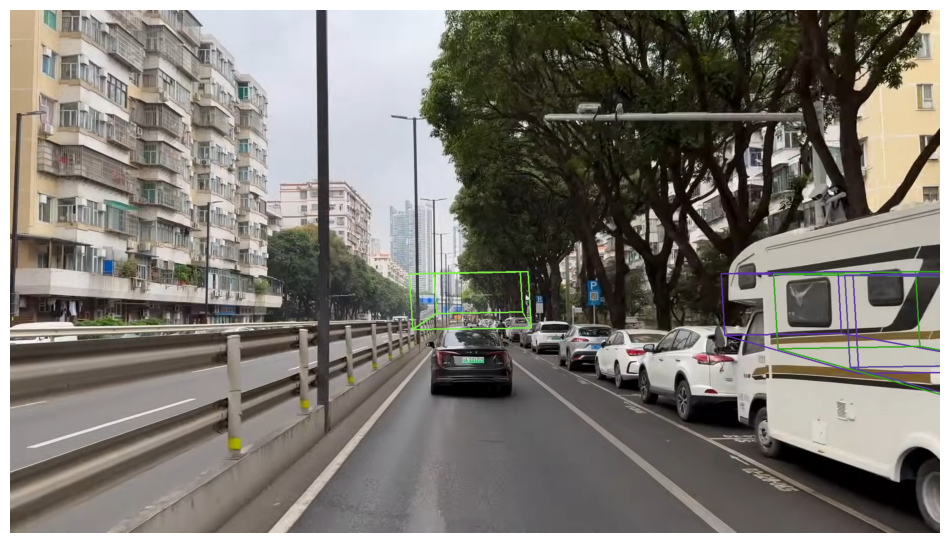

In [17]:
# Example 4: Using custom camera parameters
image_path = "./VLA_scene_understand/4. 复杂场景理解/6. 右侧长排车辆/2_2.png"

# Generate camera parameters using our function (since we don't have original camera params)
cam_params = generate_camera_params(image_path, fov=60)

# Call API to get 3D bounding box results
bbox_3d_results = [{'bbox_3d': [0.0, 0.8, 14.5, 4.6, 1.5, 1.8, 0.0, -0.49, -0.01], 'label': 'bottle'},
                   {'bbox_3d': [4.7, 0.9, 10.2, 4.7, 1.7, 1.8, 0.0, -0.49, -0.01], 'label': 'bottle'},
                   {'bbox_3d': [4.7, 0.9, 8.0, 4.7, 1.7, 1.8, 0.0, -0.49, -0.01], 'label': 'bottle'},
                   {'bbox_3d': [4.7, 0.9, 6.0, 4.7, 1.7, 1.8, 0.0, -0.49, -0.01], 'label': 'bottle'}]

# Display the 3D bounding boxes visualization in notebook
fig = draw_3dbboxes(image_path, cam_params, bbox_3d_results)
if fig is not None:
    plt.show()
